In [1]:
import ipyfilite

uploader = ipyfilite.FileUploadLite()
await uploader.request()
uploader.close()
upload_path = uploader.value[0].path

Enter filepath: hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib


In [2]:
#%pip install gribscan

import gribscan

In [3]:
import uuid
from pathlib import Path

index_path = Path(".") / f"{upload_path.stem}.{uuid.uuid4()}.index"

In [4]:
gribscan.write_index(str(upload_path), index_path)

In [5]:
magician = gribscan.Magician()
ref = gribscan.grib_magic([index_path], magician)

In [6]:
import json

ref = json.loads(json.dumps(ref).replace(
    json.dumps(str(upload_path)),
    json.dumps("https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib"),
))

In [7]:
ref = next(iter(ref.values()))
ref

{'crwc/0.0.0': ['https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib',
  0,
  5238095],
 'cswc/0.0.0': ['https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib',
  5238095,
  5238095],
 'q/0.0.0': ['https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib',
  10476190,
  5238095],
 'o3/0.0.0': ['https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib',
  15714285,
  5238095],
 'clwc/0.0.0': ['https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib',
  20952380,
  5238095],
 'ciwc/0.0.0': ['https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib',
  26190475,
  5238095],
 'cc/0.0.0': ['ht

In [8]:
import dask
import zarr

In [9]:
#%pip install aiohttp
import aiohttp
import fsspec
import xarray as xr

ds = xr.open_dataset(
    "reference://", engine="zarr", backend_kwargs=dict(
        storage_options=dict(fo=ref),
    ), consolidated=False,
)
ds

<xarray.Dataset>
Dimensions:  (time: 3, level: 5, cell: 654400)
Coordinates:
  * level    (level) int64 1 2 3 4 5
  * time     (time) datetime64[ns] 2020-07-21 2020-07-21T12:00:00 2020-07-22
Dimensions without coordinates: cell
Data variables:
    cc       (time, level, cell) float64 ...
    ciwc     (time, level, cell) float64 ...
    clwc     (time, level, cell) float64 ...
    crwc     (time, level, cell) float64 ...
    cswc     (time, level, cell) float64 ...
    o3       (time, level, cell) float64 ...
    q        (time, level, cell) float64 ...
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          0
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.Ma...

In [10]:
ds.nbytes

549696064

In [11]:
da = ds["q"]
da

<xarray.DataArray 'q' (time: 3, level: 5, cell: 654400)>
[9816000 values with dtype=float64]
Coordinates:
  * level    (level) int64 1 2 3 4 5
  * time     (time) datetime64[ns] 2020-07-21 2020-07-21T12:00:00 2020-07-22
Dimensions without coordinates: cell
Attributes: (12/15)
    paramId:                    133
    dataType:                   fc
    numberOfPoints:             654400
    typeOfLevel:                hybrid
    stepUnits:                  1
    stepType:                   instant
    ...                         ...
    name:                       Specific humidity
    cfName:                     specific_humidity
    cfVarName:                  q
    missingValue:               3.4028234663852886e+38
    NV:                         276
    gridDefinitionDescription:  Gaussian latitude/longitude

MaskIndex(MaskIndex(MaskIndex(MaskIndex(GRIBReader(hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib),[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104]),[2, 9, 16, 23, 30, 37, 44, 51, 58, 65, 72, 79, 86, 93, 100]),[0, 5, 10]),[])

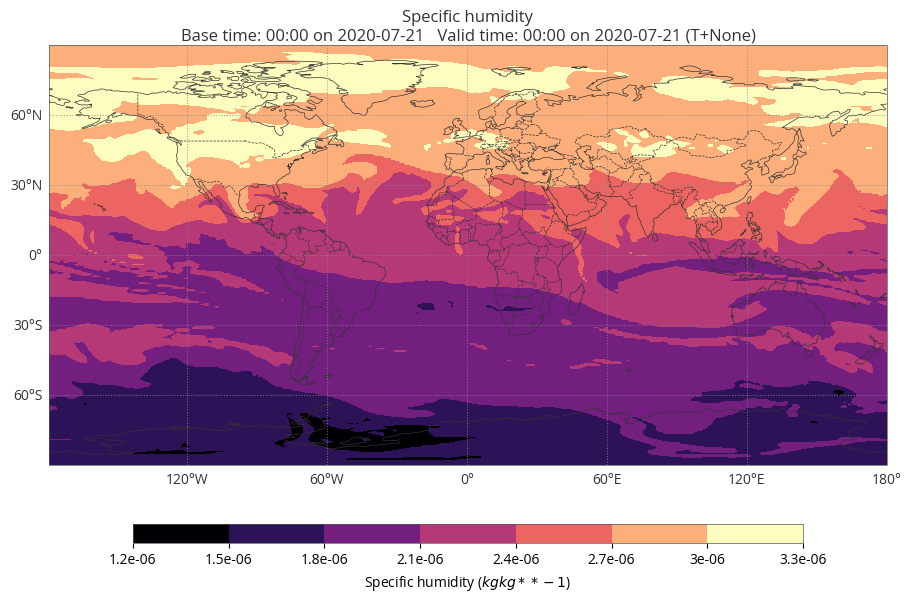

In [14]:
import earthkit
import earthkit.maps
import earthkit.plots
import earthkit.plots.quickmap


data_local = earthkit.data.from_source("file", "hplp_ml_reduced_gg_all_params_steps_levels_1-5_steps_0_12_24.grib")
da_local = data_local[0:]
da_x_local = da_local.to_xarray()

display(da_local.sel(shortName="q").sel(level=1).sel(datetime=43200000000000))
earthkit.maps.quickplot(data_local.sel(shortName="q").sel(level=1).sel(step=0))


<xarray.DataArray 'q' (time: 1, hybrid: 5, values: 654400)>
[3272000 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 2020-07-21
    step        timedelta64[ns] 12:00:00
  * hybrid      (hybrid) float64 1.0 2.0 3.0 4.0 5.0
    latitude    (values) float64 ...
    longitude   (values) float64 ...
    valid_time  (time) datetime64[ns] ...
Dimensions without coordinates: values
Attributes: (12/20)
    GRIB_paramId:                    133
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             654400
    GRIB_typeOfLevel:                hybrid
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_pl:                         [  20   24   28   32   36   40   44   48...
    GRIB_shortName:                  q
    GRIB_units:                      kg kg**-1
    long_name:                       Specific humidity
    units:                           kg kg**-1
    standard_name:                   specific_humidity

TypeError: 'numpy.datetime64' object is not iterable

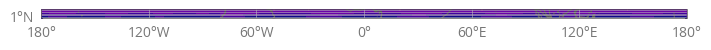

In [16]:
display(da_x_local["q"].sel(dict(step="12:00:00")))
earthkit.plots.quickmap.plot(da_x_local["q"].sel(dict(step="12:00:00")))

In [17]:
display(da_x_local["q"].sel(dict(step="12:00:00")).sel(dict(hybrid=1.0)))
earthkit.plots.quickmap.plot(da_x_local["q"].sel(dict(step="12:00:00")).sel(dict(hybrid=1.0)))

<xarray.DataArray 'q' (time: 1, values: 654400)>
[654400 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 2020-07-21
    step        timedelta64[ns] 12:00:00
    hybrid      float64 1.0
    latitude    (values) float64 ...
    longitude   (values) float64 ...
    valid_time  (time) datetime64[ns] ...
Dimensions without coordinates: values
Attributes: (12/20)
    GRIB_paramId:                    133
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             654400
    GRIB_typeOfLevel:                hybrid
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_pl:                         [  20   24   28   32   36   40   44   48...
    GRIB_shortName:                  q
    GRIB_units:                      kg kg**-1
    long_name:                       Specific humidity
    units:                           kg kg**-1
    standard_name:                   specific_humidity

IndexError: list index out of range

<Figure size 700x600 with 0 Axes>

<xarray.DataArray 'q' (time: 3, level: 5, cell: 654400)>
[9816000 values with dtype=float64]
Coordinates:
  * level    (level) int64 1 2 3 4 5
  * time     (time) datetime64[ns] 2020-07-21 2020-07-21T12:00:00 2020-07-22
Dimensions without coordinates: cell
Attributes: (12/15)
    paramId:                    133
    dataType:                   fc
    numberOfPoints:             654400
    typeOfLevel:                hybrid
    stepUnits:                  1
    stepType:                   instant
    ...                         ...
    name:                       Specific humidity
    cfName:                     specific_humidity
    cfVarName:                  q
    missingValue:               3.4028234663852886e+38
    NV:                         276
    gridDefinitionDescription:  Gaussian latitude/longitude

ValueError: different number of values and points

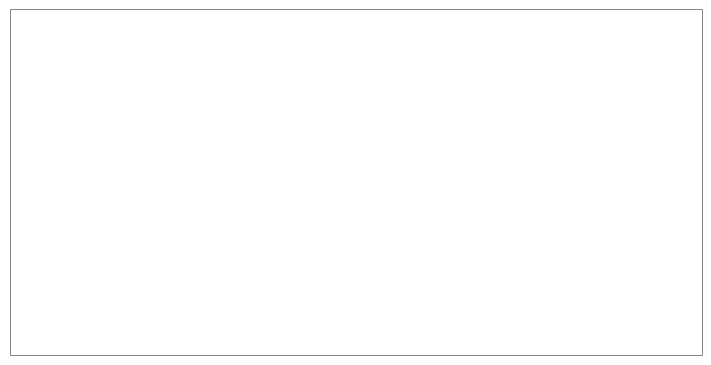

In [18]:
# remote data
display(ds["q"])
earthkit.plots.quickmap.plot(ds["q"]) 